In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import numpy as np
import fnmatch
import seaborn as sns
sns.set(style="whitegrid")

In [3]:
#Seteo directorio a los datos
os.chdir('/home/rocio/Documents/Curso_UC/heterogeneity_activity_recognition/Activity_recognition_exp')

In [4]:
files = os.listdir('.')
files

['Watch_accelerometer.csv',
 'Phones_accelerometer.csv',
 'Watch_gyroscope.csv',
 'readme.txt',
 'Phones_gyroscope.csv']

## Ejercicio 1: Cargar y explorar los datos del acelerómetro de los teléfonos

**Trabajaremos inicialmente con el acelerómetro del teléfono (`df_subset_ph_acc,(Ph_acc, en esta notebook)`).**

 **Qué hacer:** 
- Mostrar las primeras 5 filas.
- Hacer un gráfico de barras que muestre la distribucion de muestras por actividad

 **¿Por qué es importante?:** Entender la estructura y el contenido del dataset.

 **Preguntas de reflexión:**
- ¿Todas las columnas parecen relevantes para modelar actividades?
- ¿Hay columnas que parecen ser tiempo o identificadores?

In [5]:
Ph_acc = pd.read_csv(files[1],header=0) #telefono accelerometer

In [ ]:
Ph_acc.head(5) 

,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt
0,0,1424696633908,1424696631913248572,-5.958191,0.688065,8.135345,a,nexus4,nexus4_1,stand
1,1,1424696633909,1424696631918283972,-5.952240,0.670212,8.136536,a,nexus4,nexus4_1,stand
2,2,1424696633918,1424696631923288855,-5.995087,0.653549,8.204376,a,nexus4,nexus4_1,stand
3,3,1424696633919,1424696631928385290,-5.942718,0.676163,8.128204,a,nexus4,nexus4_1,stand
4,4,1424696633929,1424696631933420691,-5.991516,0.641647,8.135345,a,nexus4,nexus4_1,stand


In [7]:
Ph_acc.describe(include="all") #Metricas principales de los datos

,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt
count,1.306248e+07,1.306248e+07,1.306248e+07,1.306248e+07,1.306248e+07,1.306248e+07,13062475,13062475,13062475,11279275
unique,NaN,NaN,NaN,NaN,NaN,NaN,9,4,8,6
top,NaN,NaN,NaN,NaN,NaN,NaN,e,nexus4,nexus4_2,walk
freq,NaN,NaN,NaN,NaN,NaN,NaN,1614999,6240983,3149186,2192401
mean,1.240761e+05,1.424745e+12,6.807797e+17,-1.704579e+00,1.595409e-01,8.931753e+00,NaN,NaN,NaN,NaN
std,9.239057e+04,4.390389e+07,7.116076e+17,3.859088e+00,1.552040e+00,2.262952e+00,NaN,NaN,NaN,NaN
min,0.000000e+00,1.424687e+12,4.507724e+11,-3.881207e+01,-2.249512e+01,-1.342387e+01,NaN,NaN,NaN,NaN
25%,5.112700e+04,1.424697e+12,5.523131e+13,-4.012682e+00,-6.961212e-01,7.738060e+00,NaN,NaN,NaN,NaN
50%,1.037980e+05,1.424778e+12,3.506028e+14,-2.145178e+00,1.532270e-01,9.063251e+00,NaN,NaN,NaN,NaN
75%,1.740970e+05,1.424783e+12,1.424778e+18,-1.532270e-01,1.037979e+00,9.921814e+00,NaN,NaN,NaN,NaN


In [8]:
Ph_acc=Ph_acc.dropna() #Remuevo los datos NaN

In [13]:
list(Ph_acc["gt"].unique()) #actividades

['stand', 'sit', 'walk', 'stairsup', 'stairsdown', 'bike']

In [9]:
actividad_casos = Ph_acc.groupby("gt").size()
print(actividad_casos)

gt
bike          1845557
sit           1991919
stairsdown    1615896
stairsup      1782010
stand         1851492
walk          2192401
dtype: int64


In [11]:
list(Ph_acc["User"].unique()) #usuarios

['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i']

In [14]:
list(Ph_acc["Device"].unique()) #aparatos

['nexus4_1',
 'nexus4_2',
 's3_1',
 's3_2',
 's3mini_1',
 's3mini_2',
 'samsungold_1',
 'samsungold_2']

*Hacer un gráfico de barras que muestre la distribucion de muestras por actividad*

In [15]:
actividad_casos = Ph_acc.groupby("gt").size()
print(actividad_casos)

gt
bike          1845557
sit           1991919
stairsdown    1615896
stairsup      1782010
stand         1851492
walk          2192401
dtype: int64


/tmp/ipykernel_97783/505421785.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=actividad_casos.values, y=actividad_casos.index, palette="viridis")


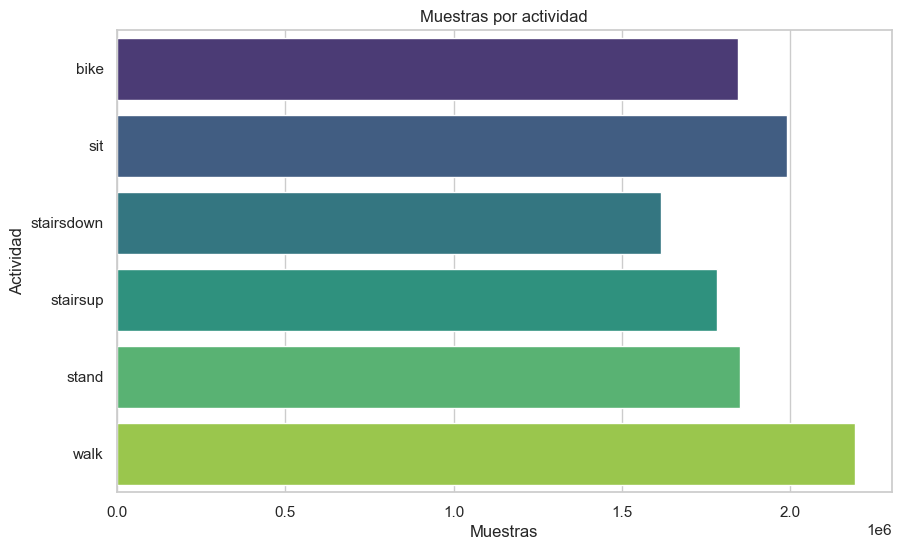

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(x=actividad_casos.values, y=actividad_casos.index, palette="viridis")
plt.title("Muestras por actividad")
plt.xlabel("Muestras")
plt.ylabel("Actividad")
plt.show()

In [17]:
actividad_casos_a = Ph_acc.where(Ph_acc["User"] == "a").groupby("gt").size()
actividad_casos_g =Ph_acc.where(Ph_acc["User"] == "g").groupby("gt").size()

print(actividad_casos_a)
print(actividad_casos_g)

gt
bike          185143
sit           239969
stairsdown    178765
stairsup      181838
stand         222854
walk          210302
dtype: int64
gt
bike          189810
sit           231827
stairsdown    185210
stairsup      176814
stand         224732
walk          270200
dtype: int64


/tmp/ipykernel_97783/2075649941.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=actividad_casos.values, y=actividad_casos.index, palette="viridis",ax=axes[0])
/tmp/ipykernel_97783/2075649941.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=actividad_casos_a.values, y=actividad_casos_a.index, palette="viridis",ax=axes[1])
/tmp/ipykernel_97783/2075649941.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=actividad_casos_g.values, y=actividad_casos_g.index, palette="viridis",ax=axes[2])


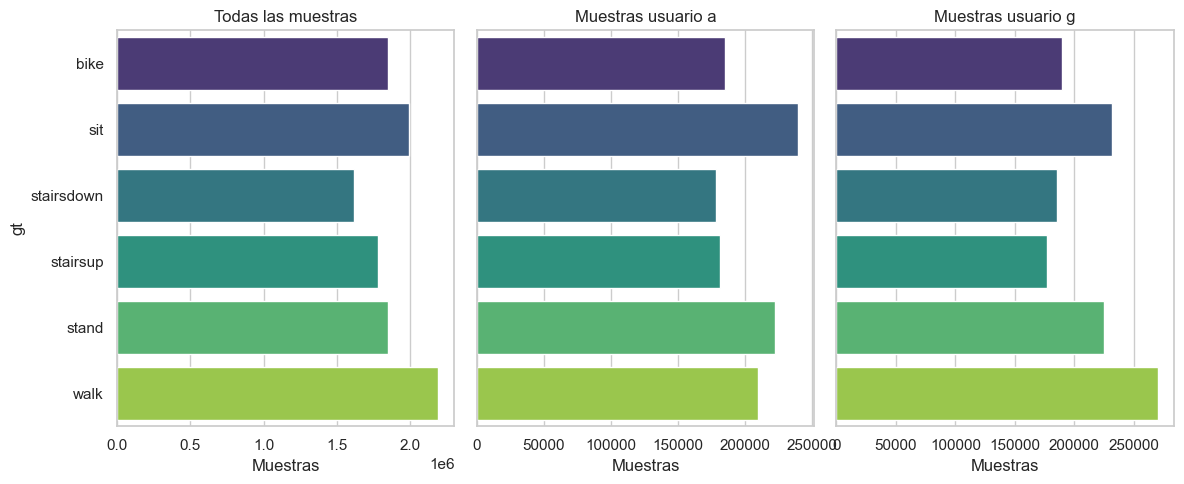

In [18]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 5), sharey=True)

sns.barplot(x=actividad_casos.values, y=actividad_casos.index, palette="viridis",ax=axes[0])
axes[0].set_title("Todas las muestras")
axes[0].set_xlabel("Muestras")
sns.barplot(x=actividad_casos_a.values, y=actividad_casos_a.index, palette="viridis",ax=axes[1])
axes[1].set_title("Muestras usuario a")
axes[1].set_xlabel("Muestras")
sns.barplot(x=actividad_casos_g.values, y=actividad_casos_g.index, palette="viridis",ax=axes[2])
axes[2].set_title("Muestras usuario g")
axes[2].set_xlabel("Muestras")

plt.tight_layout()
plt.show()

La mayoria de las muestras se encuentran en walk, sit y luego en bike cuando analizamos todos los usuarios juntos y algunos en particular. 


**Preguntas de reflexión:**

El dataset contiene información relacionada con mediciones de ubicación y tiempo correspondientes a diferentes usuarios, junto con las actividades que realizaron. Además, incluye el detalle de los dispositivos utilizados para cada medición.

En particular, algunas columnas parecen actuar como identificadores o marcas temporales. Las primeras columnas hacen referencia al tiempo de la medición, seguidas por las coordenadas espaciales (x, y, z) que describen la posición del usuario.

Sin embargo, no todas las columnas parecen ser relevantes para representar la actividad. Las coordenadas espaciales podrían ser las variables más explicativas para caracterizar el movimiento asociado a cada actividad.

# Ejercicio 2: Estadísticas básicas de 'x', 'y', 'z'

**Qué hacer:**

Calcular media, desviación estándar, valores máximo y mínimo de las señales del acelerómetro ('x', 'y', 'z').
Hacer un histograma de cada eje y Boxplots

**¿Por qué es importante?**: Ver rangos, outliers y planificar normalizaciones.


Calcular media, desviación estándar, valores máximo y mínimo de las señales del acelerómetro ('x', 'y', 'z').

In [19]:
print(Ph_acc["x"].min())
print(Ph_acc["x"].max())
print(Ph_acc["x"].mean())
print(Ph_acc["x"].std())

-38.812073
27.92894
-1.59438526722108
3.94829999338675


In [23]:
print(Ph_acc["y"].min())
print(Ph_acc["y"].max())
print(Ph_acc["y"].mean())
print(Ph_acc["y"].std())

-22.495117
20.808151
0.1531095317082668
1.5473211336443853


In [24]:
print(Ph_acc["z"].min())
print(Ph_acc["z"].max())
print(Ph_acc["z"].mean())
print(Ph_acc["z"].std())

-13.423874
39.31801
8.91110185635295
2.2806041778892143


*Hacer un histograma de cada eje y Boxplots*

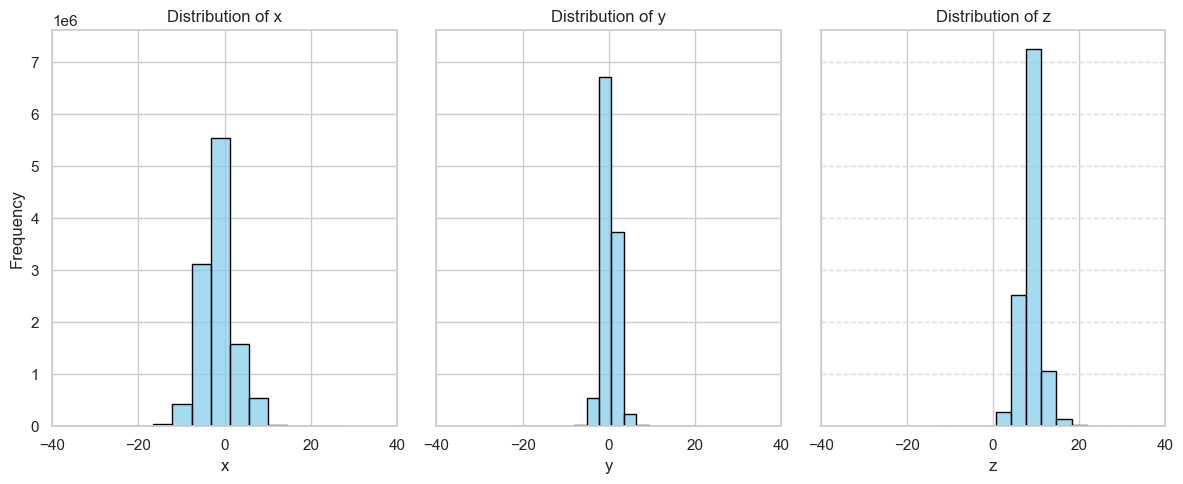

In [41]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 5), sharey=True)
sns.histplot(Ph_acc["x"], bins=15, color='skyblue', edgecolor='black', ax=axes[0])
axes[0].set_title('Distribution of x')
axes[0].set_ylabel('Frequency')
axes[0].set_xlim(-40, 40)
sns.histplot(Ph_acc["y"], bins=15, color='skyblue', edgecolor='black', ax=axes[1])
axes[1].set_title('Distribution of y')
axes[1].set_ylabel('Frequency')
axes[1].set_xlim(-40, 40)
sns.histplot(Ph_acc["z"], bins=15, color='skyblue', edgecolor='black', ax=axes[2])
axes[2].set_title('Distribution of z')
axes[2].set_ylabel('Frequency')
axes[2].set_xlim(-40, 40)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.tight_layout()
plt.show()

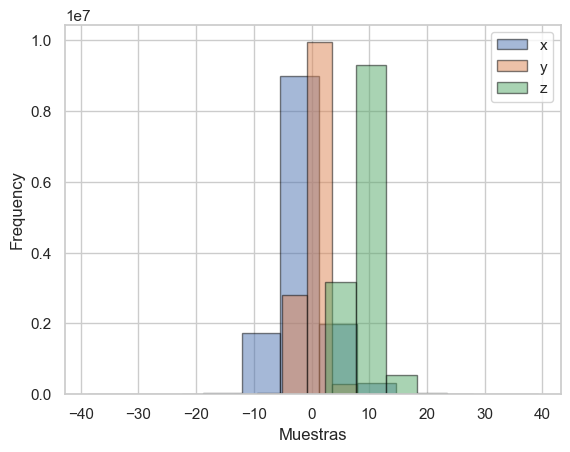

In [ ]:
#Si incluyo todos en el mismo grafico

plt.hist(Ph_acc["x"], bins=10, alpha=0.5, label='x', edgecolor='black')
plt.hist(Ph_acc["y"], bins=10, alpha=0.5, label='y', edgecolor='black')
plt.hist(Ph_acc["z"], bins=10, alpha=0.5, label='z', edgecolor='black')
plt.xlabel("Muestras")
plt.ylabel('Frequency')
plt.legend(loc='upper right')
plt.show()

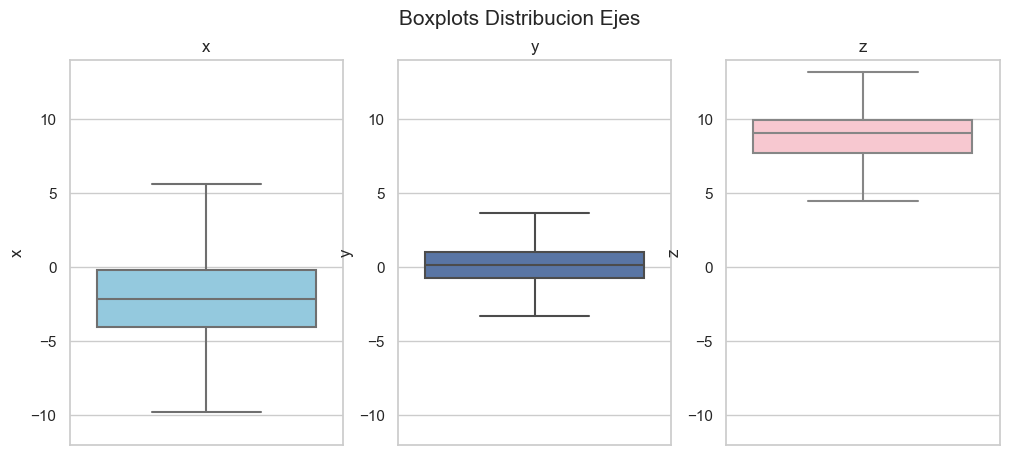

In [9]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 5))

sns.boxplot(y='x', data=Ph_acc, ax=axes[0],color='skyblue',showfliers=False)
axes[0].set_title('x')
axes[0].set(ylim=(-12, 14))

sns.boxplot(y='y', data=Ph_acc, ax=axes[1],showfliers=False)
axes[1].set_title('y')
axes[1].set(ylim=(-12, 14))

sns.boxplot(y='z', data=Ph_acc, ax=axes[2],color='pink',showfliers=False)
axes[2].set_title('z')
axes[2].set(ylim=(-12, 14))

fig.suptitle('Boxplots Distribucion Ejes', fontsize=15)
plt.show()

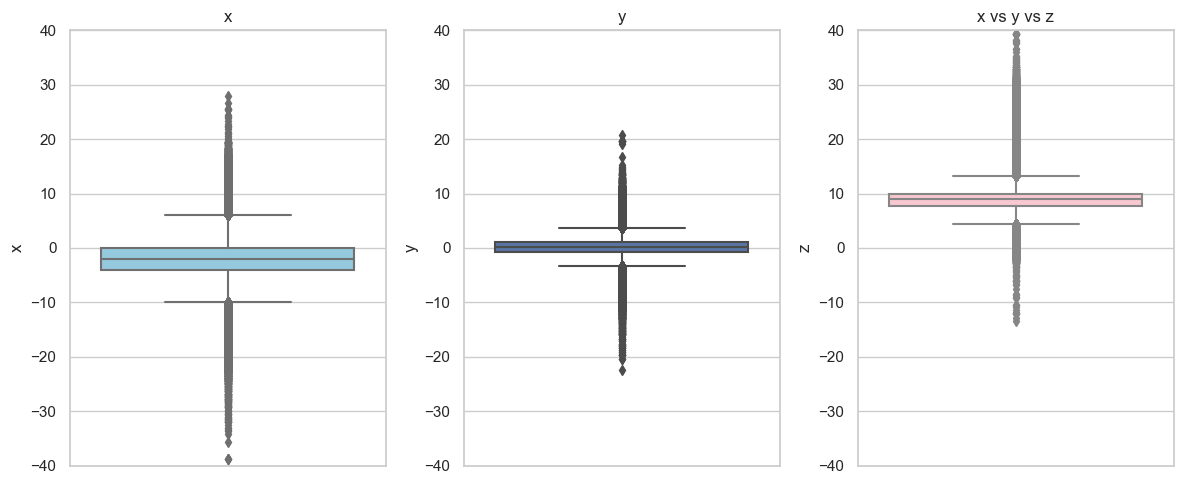

In [ ]:
#Si incluyo los outliers

fig, axes = plt.subplots(ncols=3, figsize=(12, 5))

sns.boxplot(y='x', data=Ph_acc, ax=axes[0],color='skyblue')
axes[0].set_title('x')
axes[0].set(ylim=(-40, 40))

sns.boxplot(y='y', data=Ph_acc, ax=axes[1])
axes[1].set_title('y')
axes[1].set(ylim=(-40, 40))

sns.boxplot(y='z', data=Ph_acc, ax=axes[2],color='pink')
axes[2].set_title('z')
axes[2].set(ylim=(-40, 40))


plt.tight_layout()
plt.show()

**Preguntas de reflexión:**

La distribución de los ejes es distinta, con los valores más elevados en el eje z. El eje x y el eje y se encuentran centrados en el cero y en el caso de x con valores mayoritariamente negativos. La dispersión es mayor en el eje x. 

Dada la diferencia en los valores de los ejes, sería conveniente aplicar alguna normalización previa a la modelización. Esto evitaría valores espureos asociados a la diferencia de valores en los ejes. 

Se podrían, por ejemplo, estandarizar las variables, i.e., restar la media y dividir por el desvío estándar de cada eje, con el objetivo de que todas las variables queden en un rango de valores comparable.

# Ejercicio 3: Filtrar actividades específicas (walk vs sit)

Qué hacer:

Filtra el DataFrame df_subset_ph_acc (ph_acc, en esta notebook) para obtener dos nuevos subconjuntos: uno con los registros de la actividad walk y otro de sit.
Muestra el número de registros para cada actividad.
Representa los resultados en un gráfico de barras comparando el número de muestras de walk vs sit.

**¿Por qué es importante?:**

Filtrar datos por condiciones específicas es fundamental para realizar análisis focalizados.
Visualizar el balance entre clases ayuda a detectar posibles problemas de desbalanceo, muy relevantes para la calidad de los modelos de predicción.
 
 **Preguntas para reflexión:**

¿Es equilibrado el número de muestras entre walk y sit?
¿Qué problemas podría traer un desbalance muy grande entre clases?
¿Cómo podrías corregir un desbalance si fuera necesario?

In [25]:
Ph_acc_sit = Ph_acc[Ph_acc["gt"] == "sit"]
Ph_acc_walk = Ph_acc[Ph_acc["gt"] == "walk"]

In [26]:
#la dimension de Ph_acc_sit
Ph_acc_sit.shape

(1991919, 10)

In [27]:
Ph_acc_walk.shape   

(2192401, 10)

In [28]:
#Reordeno para poder graficarlos juntos
grafico = Ph_acc.loc[(Ph_acc["gt"] == "sit") | (Ph_acc["gt"] == "walk")].groupby('gt').size()

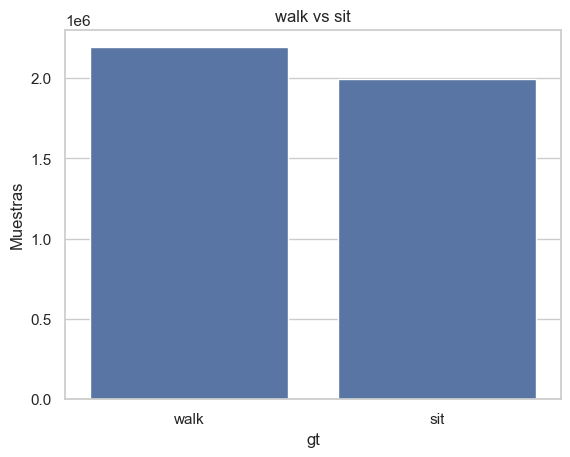

In [29]:
sns.barplot(y=grafico.values, x=grafico.index,orient='v')
plt.gca().invert_xaxis()
plt.title("walk vs sit")
plt.ylabel("Muestras")
plt.show()

In [30]:
#Si especifico un usuario en particular
grafico_a = Ph_acc.loc[
    ((Ph_acc["gt"] == "sit") | (Ph_acc["gt"] == "walk")) &
    (Ph_acc["User"] == "a")].groupby('gt').size()

grafico_g = Ph_acc.loc[
    ((Ph_acc["gt"] == "sit") | (Ph_acc["gt"] == "walk")) &
    (Ph_acc["User"] == "g")].groupby('gt').size()

grafico_c = Ph_acc.loc[
    ((Ph_acc["gt"] == "sit") | (Ph_acc["gt"] == "walk")) &
    (Ph_acc["User"] == "c")].groupby('gt').size()


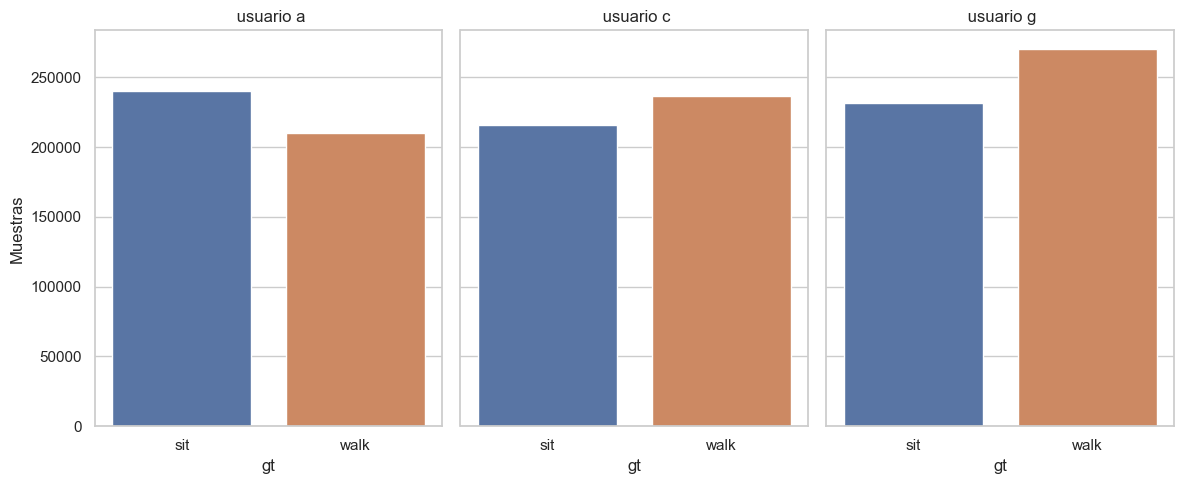

In [39]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 5), sharey=True)

sns.barplot(y=grafico_a.values, x=grafico_a.index,orient='v',ax=axes[0])
axes[0].set_title(" usuario a")
axes[0].set_xlabel("gt")
axes[0].set_ylabel("Muestras")

sns.barplot(y=grafico_c.values, x=grafico_c.index,orient='v',ax=axes[1])
axes[1].set_title(" usuario c")
axes[1].set_xlabel("gt")
sns.barplot(y=grafico_g.values, x=grafico_g.index,orient='v',ax=axes[2])
axes[2].set_title(" usuario g")
axes[2].set_xlabel("gt")

plt.tight_layout()
plt.show()

 **Preguntas para reflexión:**

El número de muestras walk vs. sit no está equilibrado. En total, son mayores las muestras de walk, aunque pueden variar dependiendo del usuario que se analice.
Un desbalance muy grande podría causar información sesgada hacia una actividad, en este caso, la que posea más datos.
Si la cantidad de datos no es muy escasa, se podría considerar una submuestra de los datos mayoritarios para balancearlos con los minoritarios. 

# Ejercicio 4: Agrupación por actividad y Gráfico comparativo de actividades

**Qué hacer:**

Agrupar por tipo de actividad y calcular medias de x, y, z.
Hacer un gráfico de barras de medias de x, y, z para 'walk', 'sit' y 'stairsup'.

**¿Por qué es importante?:**

Permite comparar globalmente la dinámica de cada actividad y ver si son fáciles de distinguir.
Visualizar los patrones ayuda a detectar actividades más fáciles o difíciles de clasificar.

Interpretación esperada: Actividades dinámicas como caminar, correr, subir escaleras deberían tener aceleraciones mayores que sentarse.

**Preguntas para reflexión:**

¿Qué actividades parecen más similares entre sí?
¿Qué actividades podrían confundirse en un modelo de clasificación?
¿Qué actividad tiene el perfil de aceleración más alto?
¿Podríamos usar esta diferencia directamente como una característica para clasificación?

*Agrupar por tipo de actividad y calcular medias de x, y, z.*

In [31]:
print(Ph_acc.groupby("gt")['x'].mean())
print(Ph_acc.groupby("gt")['y'].mean())
print(Ph_acc.groupby("gt")['z'].mean())

gt
bike         -1.337308
sit           3.762870
stairsdown   -3.216161
stairsup     -3.903135
stand        -2.419891
walk         -2.909116
Name: x, dtype: float64
gt
bike         -0.068326
sit           0.155249
stairsdown    0.198635
stairsup      0.124511
stand         0.353311
walk          0.158189
Name: y, dtype: float64
gt
bike          9.399014
sit           8.438220
stairsdown    8.869204
stairsup      8.482344
stand         9.194293
walk          9.070242
Name: z, dtype: float64


*Hacer un gráfico de barras de medias de x, y, z para 'walk', 'sit' y 'stairsup'.*

In [32]:
Ph_acc_d = Ph_acc.loc[(Ph_acc["gt"] == "sit") | (Ph_acc["gt"] == "walk")| (Ph_acc["gt"] == "stairsup")]

In [33]:
Ph_acc_d.groupby("gt")['y'].mean()

gt
sit         0.155249
stairsup    0.124511
walk        0.158189
Name: y, dtype: float64

In [34]:
Ph_acc_d.groupby("gt")['z'].mean()

gt
sit         8.438220
stairsup    8.482344
walk        9.070242
Name: z, dtype: float64

In [35]:
Ph_acc_d.groupby("gt")['x'].mean()

gt
sit         3.762870
stairsup   -3.903135
walk       -2.909116
Name: x, dtype: float64

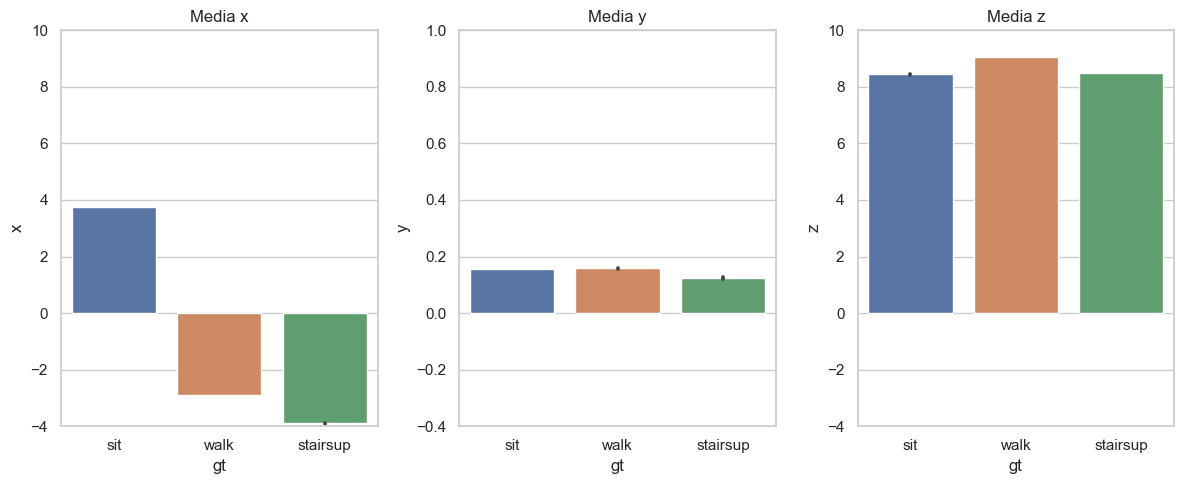

In [14]:
fig, axes = plt.subplots(ncols=3, figsize=(12, 5))

sns.barplot(Ph_acc_d, x="gt", y="x",ax=axes[0])
axes[0].set_title('Media x')
axes[0].set(ylim=(-4, 10))

sns.barplot(Ph_acc_d, x="gt", y="y",ax=axes[1])
axes[1].set_title('Media y')
axes[1].set(ylim=(-0.4, 1))

sns.barplot(Ph_acc_d, x="gt", y="z",ax=axes[2])
axes[2].set_title('Media z')
axes[2].set(ylim=(-4, 10))

plt.tight_layout()
plt.show()

In [36]:
#Si miro las actividades en terminos de la magnitud del vector 
Ph_acc_d['mod'] = np.sqrt(Ph_acc_d['x']**2 + Ph_acc_d['y']**2 + Ph_acc_d['z']**2)

/tmp/ipykernel_97783/1862506536.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Ph_acc_d['mod'] = np.sqrt(Ph_acc_d['x']**2 + Ph_acc_d['y']**2 + Ph_acc_d['z']**2)


/home/rocio/miniconda3/lib/python3.7/site-packages/ipykernel_launcher.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  This is separate from the ipykernel package so we can avoid doing imports until


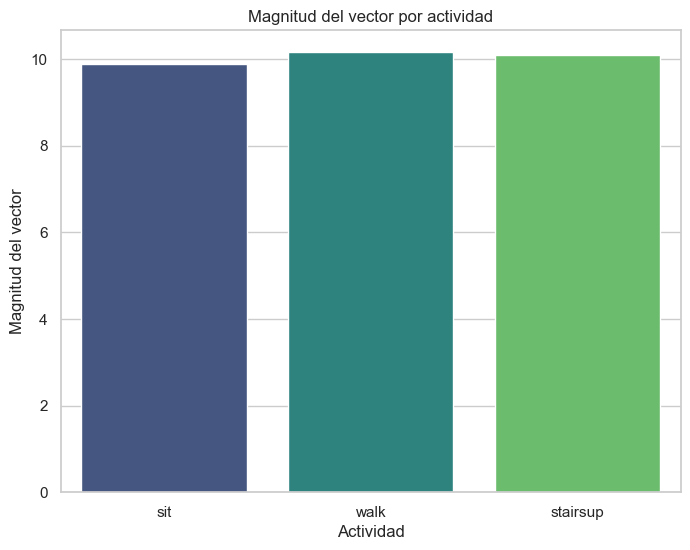

In [ ]:
#Si las grafico en barra por actividad
plt.figure(figsize=(8, 6))
sns.barplot(x='gt', y='mod', data=Ph_acc_d, ci=None, palette="viridis")
plt.title("Magnitud del vector por actividad")
plt.xlabel("Actividad")
plt.ylabel("Magnitud del vector")
plt.show()

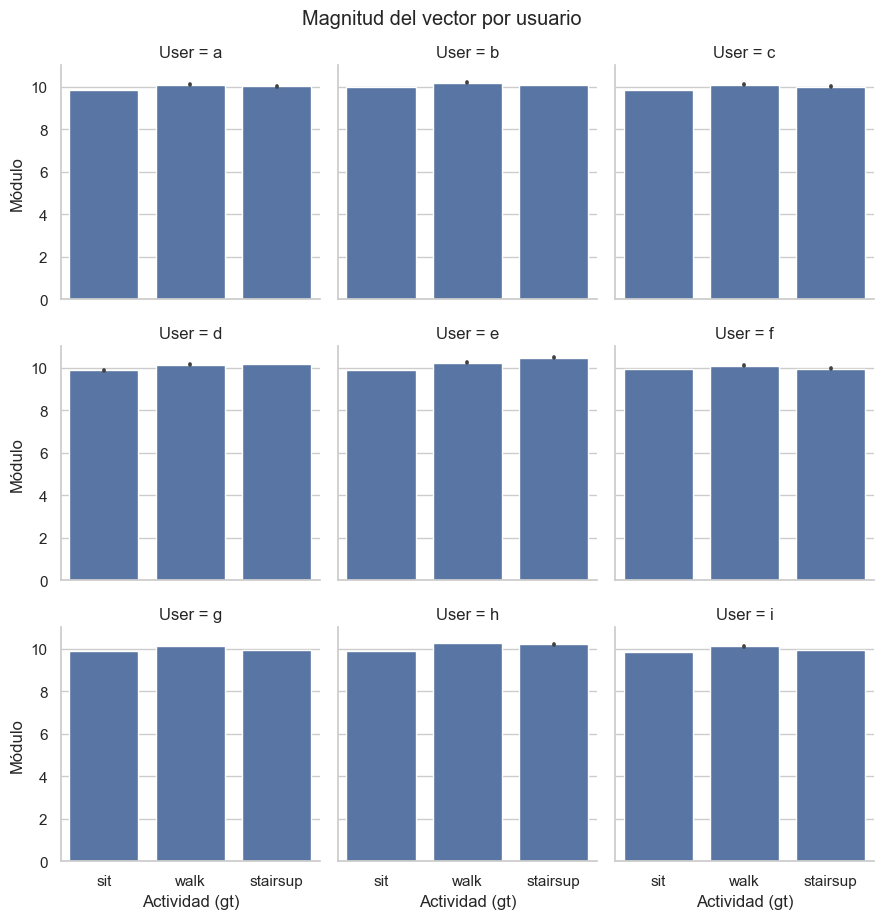

In [13]:
g = sns.FacetGrid(Ph_acc_d, col="User", sharey=True, col_wrap=3)
g.map(sns.barplot, "gt", "mod", order=Ph_acc_d['gt'].unique())
g.set_axis_labels("Actividad (gt)", "Módulo")
g.fig.suptitle("Magnitud del vector por usuario", y=1.02)
plt.show()


**Preguntas para reflexión:**

La distribución de los valores cambia dependiendo de la actividad, pudiendo esta variar en signo y en magnitud.
Dependiendo del eje, algunas actividades son más similares, pero varían en función del eje considerado.

Por un lado, walk tiene la magnitud más alta en el eje z y el eje y, mientras que en el eje x, stairsup y sit tienen los valores absolutos más altos.   

Al considerar el módulo de la aceleración, esta es mayor en walk, seguida de stairsup y sit. Según el usuario, estos valores varían muy poco.

Podrían utilizarse las diferentes características en x,y,z para clasificar las actividades y descartar las similitudes que tienen dentro de cada eje. 

# Ejercicio 5: Clasificación de actividades

 Qué hacer:

Crea una nueva columna activity_type en el DataFrame, clasificando las actividades de la columna gt en "Dinámica" (walk, stairsup, stairsdown, run, bike) o "Estática" (el resto).
Muestra una tabla con las primeras filas (head()) mostrando gt y activity_type.
Representa en una gráfica de barras la cantidad de muestras de actividades "Dinámica" y "Estática".

**¿Por qué es importante?:**

Saber transformar datos categóricos en grupos más simples es clave para entender mejor los datos y preparar análisis o modelos más robustos.
Aprenderás a crear nuevas columnas de forma programada, un paso esencial en cualquier proyecto de análisis de datos.

**Preguntas para reflexión:**

¿Qué pasa si agregamos o quitamos actividades de la clasificación?
¿Crees que esta agrupación podría afectar a un modelo que predice tipos de actividad? ¿Por qué?
¿Qué otras maneras de agrupar actividades se te ocurren?

In [37]:
list(Ph_acc["gt"].unique())

['stand', 'sit', 'walk', 'stairsup', 'stairsdown', 'bike']

In [38]:
Ph_acc['activity_type'] = np.where((Ph_acc['gt']=="sit") | (Ph_acc['gt']=="stand"), 'Estatica', 'Dinamica')

In [39]:
Ph_acc.head()

,Index,Arrival_Time,Creation_Time,x,y,z,User,Model,Device,gt,activity_type
0,0,1424696633908,1424696631913248572,-5.958191,0.688065,8.135345,a,nexus4,nexus4_1,stand,Estatica
1,1,1424696633909,1424696631918283972,-5.952240,0.670212,8.136536,a,nexus4,nexus4_1,stand,Estatica
2,2,1424696633918,1424696631923288855,-5.995087,0.653549,8.204376,a,nexus4,nexus4_1,stand,Estatica
3,3,1424696633919,1424696631928385290,-5.942718,0.676163,8.128204,a,nexus4,nexus4_1,stand,Estatica
4,4,1424696633929,1424696631933420691,-5.991516,0.641647,8.135345,a,nexus4,nexus4_1,stand,Estatica


In [40]:
subactividad_casos = Ph_acc.groupby("activity_type").size()
subactividad_casos

activity_type
Dinamica    7435864
Estatica    3843411
dtype: int64

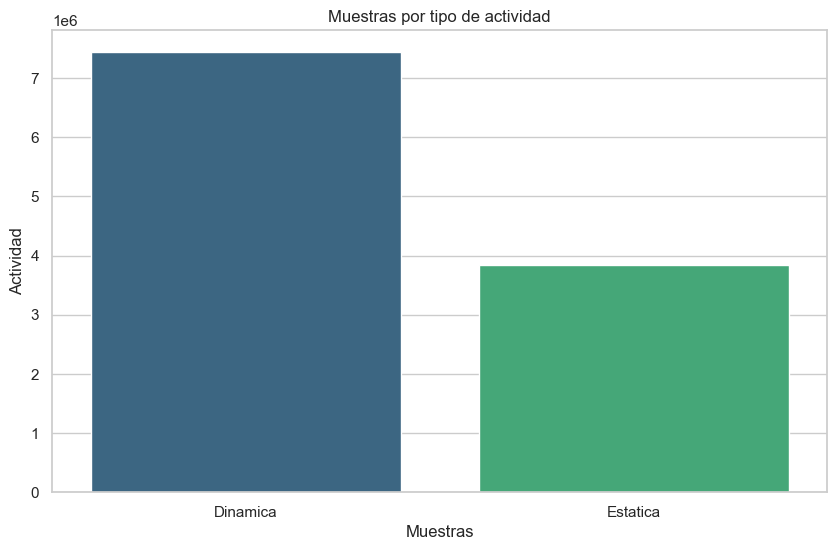

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(y=subactividad_casos.values, x=subactividad_casos.index, palette="viridis")
plt.title("Muestras por tipo de actividad")
plt.xlabel("Muestras")
plt.ylabel("Actividad")
plt.show()

In [ ]:
#Si quito la actividad stairsup and strairsdown de forma que se equiparen las actividades por clasificacion   
Ph_acc_sub = Ph_acc.loc[(Ph_acc["gt"] != "stairsup") & (Ph_acc["gt"] != "stairsdown")]

In [42]:
subactividad_casos = Ph_acc_sub.groupby("activity_type").size()
subactividad_casos

activity_type
Dinamica    4037958
Estatica    3843411
dtype: int64

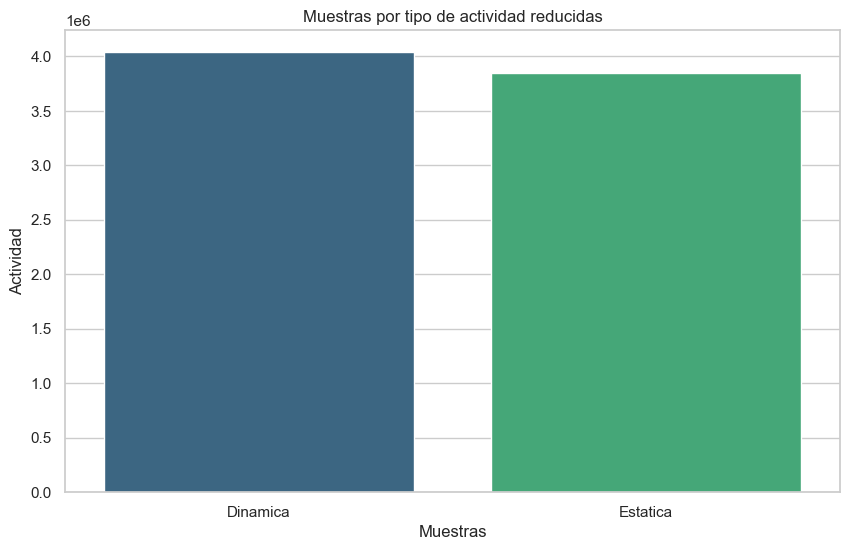

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(y=subactividad_casos.values, x=subactividad_casos.index, palette="viridis")
plt.title("Muestras por tipo de actividad reducidas")
plt.xlabel("Muestras")
plt.ylabel("Actividad")
plt.show()

In [ ]:
#Si en cambio quito walk unicamente 
Ph_acc_sub = Ph_acc.loc[(Ph_acc["gt"] != "walk")]
subactividad_casos = Ph_acc_sub.groupby("activity_type").size()

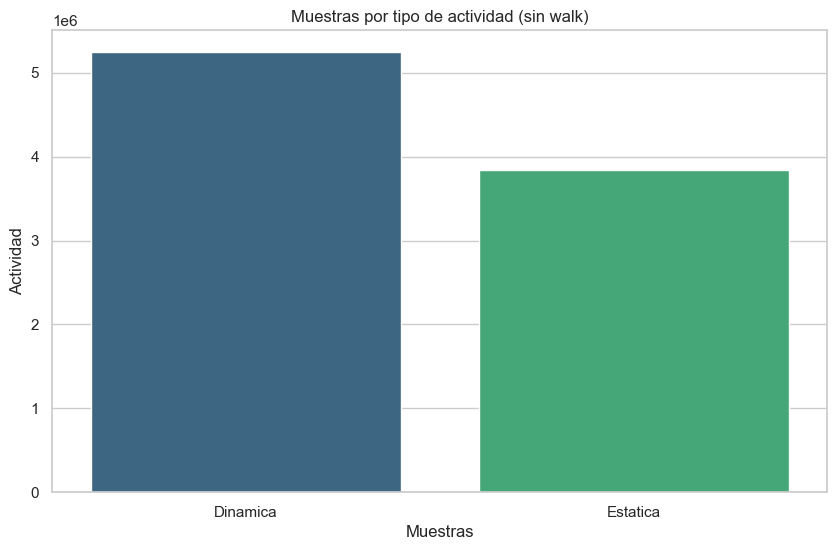

In [9]:
plt.figure(figsize=(10, 6))
sns.barplot(y=subactividad_casos.values, x=subactividad_casos.index, palette="viridis")
plt.title("Muestras por tipo de actividad (sin walk)")
plt.xlabel("Muestras")
plt.ylabel("Actividad")
plt.show()

In [ ]:
# Si agrupo en tres categorias (sit, stand), (walk,bike) , (stairsup, stairsdown)

map_dict = {
    'sit': 'Estatica',
    'stand': 'Estatica',
    'walk': 'Dinamica_Ligera',
    'bike': 'Dinamica_Ligera',
    'stairsup': 'Dinamica_Intensa',
    'stairsdown': 'Dinamica_Intensa'
}

Ph_acc['activity_type2'] = Ph_acc['gt'].map(map_dict)

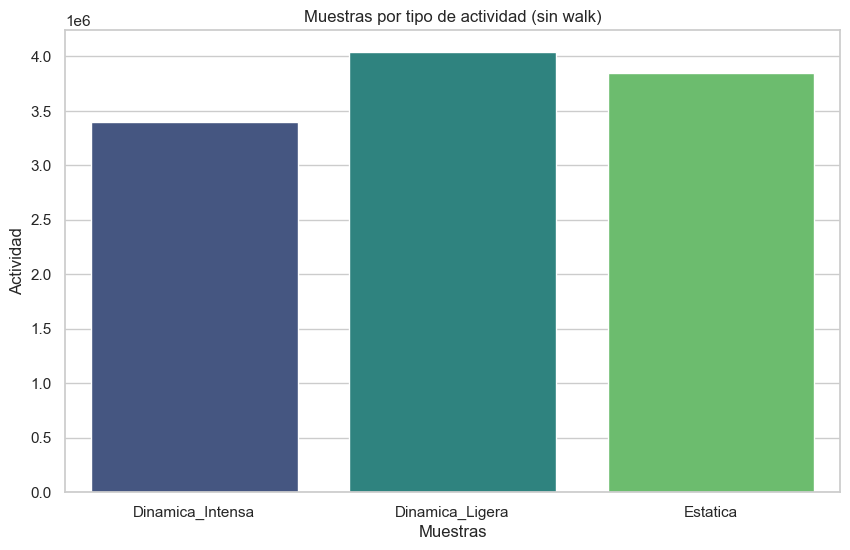

In [9]:
subactividad_casos = Ph_acc.groupby("activity_type2").size()
plt.figure(figsize=(10, 6))
sns.barplot(y=subactividad_casos.values, x=subactividad_casos.index, palette="viridis")
plt.title("Muestras por tipo de actividad (sin walk)")
plt.xlabel("Muestras")
plt.ylabel("Actividad")
plt.show()

**Preguntas para reflexión:**

El tamaño de la muestra varía según las actividades que se incluyan en cada clasificación. Esto puede limitar la capacidad predictiva del modelo ya que le quitaria informacion explicativa sobre el detalle de cada actividad. Además, podría desbalancear los datos a partir de la clasificación. También podría introducir sesgos si la selección de actividades de cada clasificación no es representativa. Sin embargo, la reagrupación de actividades puede ser útil cuando el objetivo es predecir un grupo de actividades con cierta característica y no distinguir entre todas ellas.

Por ejemplo, se podrían agrupar las actividades según el esfuerzo físico requerido. Esto permitiría clasificar, bike y walk como actividades de mayor esfuerzo continuo, mientras que stairsup y stairsdown podrían formar otro grupo relacionado con esfuerzo más intermitente. 

# Ejercicio 6: Comparativa Teléfono vs Reloj (Acelerómetro)

**Qué hacer:**

Filtra el DataFrame para quedarte sólo con las actividades walk y sit.
Crea dos subconjuntos de datos: uno para el teléfono (ph_acc_common) y otro para el reloj (wat_acc_common).
Representa en un histograma la distribución de las aceleraciones en el eje X para ambos dispositivos, en la misma gráfica.

**¿Por qué es importante?:**
Comparar datos de distintos dispositivos para las mismas actividades permite entender mejor las diferencias de captación de los sensores.
Aprenderás a utilizar filtros en pandas y a superponer múltiples distribuciones en un solo gráfico para compararlas de manera visual.

**Preguntas para reflexión:**

¿Observas diferencias claras en las distribuciones de aceleración entre el teléfono y el reloj?
¿Qué factores pueden causar esas diferencias, incluso realizando la misma actividad?
¿Qué implicaciones crees que tendría esta diferencia al entrenar un modelo de predicción?

In [43]:
Wat_acc = pd.read_csv(files[0],header=0) #reloj accelerometer

In [44]:
Wat_acc=Wat_acc.dropna() #Remuevo los datos NaN

In [45]:
ph_acc_common = Ph_acc.loc[(Ph_acc["gt"] == "sit") | (Ph_acc["gt"] == "walk")]

In [46]:
wat_acc_common= Wat_acc.loc[(Wat_acc["gt"] == "sit") | (Wat_acc["gt"] == "walk")]

*Representa en un histograma la distribución de las aceleraciones en el eje X para ambos dispositivos, en la misma gráfica.*

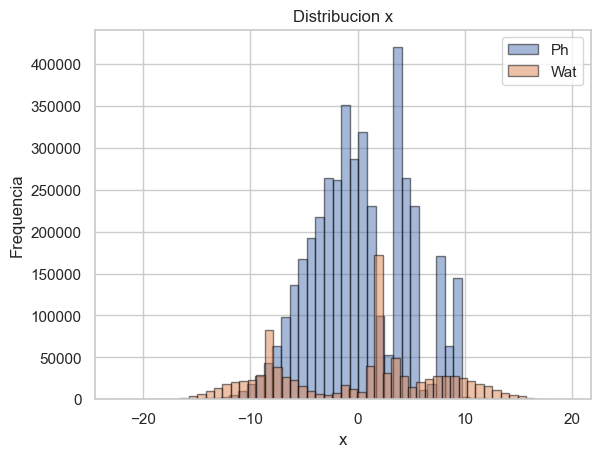

In [19]:
plt.hist(ph_acc_common["x"], bins=50, alpha=0.5, label='Ph', edgecolor='black')
plt.hist(wat_acc_common["x"], bins=50, alpha=0.5, label='Wat', edgecolor='black')
plt.title("Distribucion x")
plt.xlabel("x")
plt.ylabel('Frequencia')
plt.legend(loc='upper right')
plt.show()

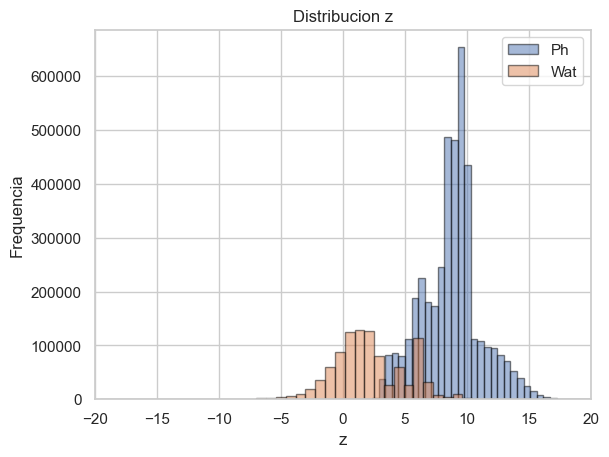

In [18]:
plt.hist(ph_acc_common["z"], bins=50,alpha=0.5, label='Ph', edgecolor='black')
plt.hist(wat_acc_common["z"], bins=50, alpha=0.5, label='Wat', edgecolor='black')
plt.title("Distribucion z")
plt.xlabel("z")
plt.xlim(-20, 20)
plt.ylabel('Frequencia')
plt.legend(loc='upper right')
plt.show()

**Preguntas para reflexión:**

Se observan diferencias en las distribuciones de aceleración entre el teléfono y el reloj. En particular, las magnitudes registradas por el teléfono son notablemente mayores que las del reloj, y la forma de las distribuciones en los ejes x, y y z también difiere entre ambos dispositivos.

Estas diferencias podrían estar causadas por los diferentes sensores utilizados en cada dispositivo y la forma en la que miden y la sensibilidad que tienen. Además, la posición  durante la actividad puede influir  en las mediciones: el teléfono suele ubicarse en un bolsillo o en la mano,mientras que el reloj está firmemente sujeto a la muñeca y refleja más los movimientos del brazo.
En este sentido, el modelo predictivo dependerá en gran medida del dispositivo desde el que provengan los datos. Podría utilizarse algún factor de corrección para equilibrar los valores de ambos sensores o entrenar modelos de forma separada.

# Ejercicio 7: Comparativa Acelerómetro vs Giroscopio (Teléfono)
**Qué hacer:**

Filtra los datos del giroscopio del teléfono para quedarte solo con las actividades walk y sit, igual que en el acelerómetro.
Representa en un histograma las distribuciones de aceleraciones en el eje X para el acelerómetro (ph_acc_common) y para el giroscopio (ph_gyr_common), en la misma gráfica.

**¿Por qué es importante?:**

Ver qué sensor aporta más información según el tipo de actividad ayuda a optimizar modelos de reconocimiento de actividades.
Entender qué diferencias existen entre acelerómetro y giroscopio permite seleccionar el sensor adecuado para cada problema.

**Preguntas para reflexión:**

¿Qué diferencias ves entre las señales del acelerómetro y el giroscopio?
¿En qué tipos de actividades crees que el giroscopio podría ser más útil que el acelerómetro?
¿Podría ser interesante combinar la información de ambos sensores?

In [10]:
Ph_gy = pd.read_csv(files[4],header=0) # telefono gyroscope

In [11]:
ph_py_common = Ph_gy.loc[(Ph_gy["gt"] == "sit") | (Ph_gy["gt"] == "walk")]

In [12]:
ph_py_common=ph_py_common.dropna() #Remuevo los datos NaN

*Representa en un histograma las distribuciones de aceleraciones en el eje X para el acelerómetro (ph_acc_common) y para el giroscopio (ph_gyr_common), en la misma gráfica.*

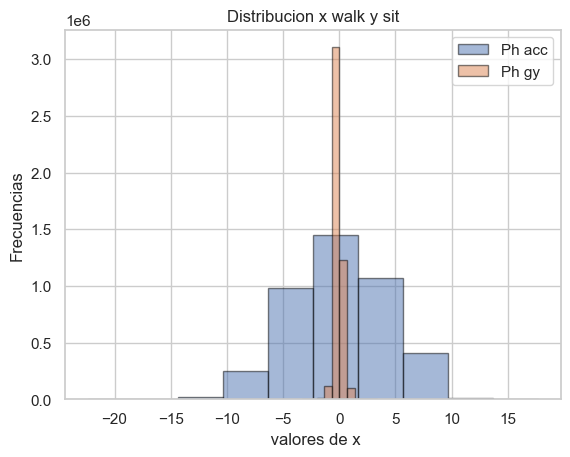

In [23]:
plt.hist(ph_acc_common["x"], bins=10, alpha=0.5, label='Ph acc', edgecolor='black')
plt.hist(ph_py_common["x"], bins=10, alpha=0.5, label='Ph gy', edgecolor='black')
plt.title("Distribucion x walk y sit")
plt.xlabel(" valores de x")
plt.ylabel("Frecuencias")
plt.legend(loc='upper right')
plt.show()

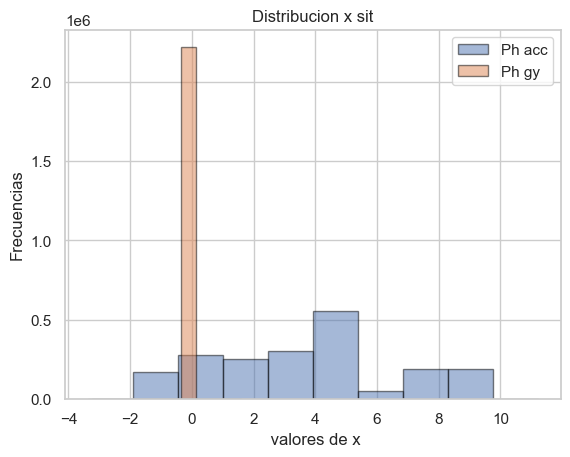

In [24]:
#Si diferencio por actividad 
plt.hist(ph_acc_common[ph_acc_common["gt"]=="sit"]["x"], bins=10, alpha=0.5, label='Ph acc', edgecolor='black')
plt.hist(ph_py_common[ph_py_common["gt"]=="sit"]["x"], bins=10, alpha=0.5, label='Ph gy', edgecolor='black')
plt.title("Distribucion x sit")
plt.xlabel(" valores de x")
plt.ylabel("Frecuencias")
plt.legend(loc='upper right')
plt.show()

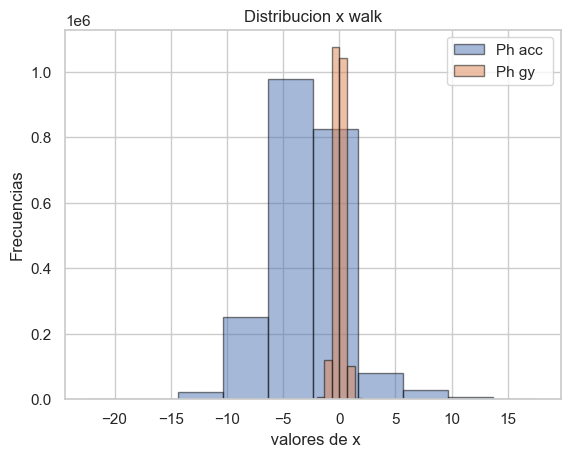

In [25]:
plt.hist(ph_acc_common[ph_acc_common["gt"]=="walk"]["x"], bins=10, alpha=0.5, label='Ph acc ', edgecolor='black')
plt.hist(ph_py_common[ph_py_common["gt"]=="walk"]["x"], bins=10, alpha=0.5, label='Ph gy ', edgecolor='black')
plt.title("Distribucion x walk")
plt.xlabel(" valores de x")
plt.ylabel("Frecuencias")
plt.legend(loc='upper right')
plt.show()

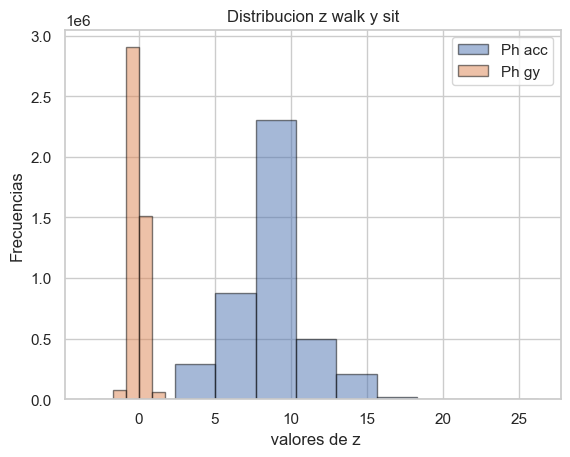

In [26]:
plt.hist(ph_acc_common["z"], bins=10, alpha=0.5, label='Ph acc', edgecolor='black')
plt.hist(ph_py_common["z"], bins=10, alpha=0.5, label='Ph gy', edgecolor='black')
plt.title("Distribucion z walk y sit")
plt.xlabel(" valores de z")
plt.ylabel("Frecuencias")
plt.legend(loc='upper right')
plt.show()

**Preguntas para reflexión:**

El giroscopio presenta señales de menor magnitud que el acelerómetro y muestra una variabilidad más acotada en sus ejes. Ambos sensores operan en escalas distintas y miden fenómenos diferentes: el acelerómetro registra aceleraciones lineales, mientras que el giroscopio mide velocidades angulares o rotaciones.

La combinación de ambas fuentes de información permite describir el movimiento de forma más completa. Por lo tanto, integrar ambas señales en el modelo puede proporcionar una representación más completa del patrón de movimiento, lo que potencialmente mejora el desempeño en la clasificación o predicción de actividades.

# Ejercicio 8: Correlación entre sensores

**Qué hacer:**

Une los datos del acelerómetro (ph_acc_common) y del giroscopio (ph_gyr_common) usando solo los ejes x, y, z, ajustando los índices.
Crea un nuevo DataFrame combinando ambos sensores.
Calcula y visualiza la matriz de correlación entre todas las variables usando un mapa de calor.

**¿Por qué es importante?:**

Entender la correlación entre sensores ayuda a detectar si hay redundancia (información duplicada) o complementariedad (información adicional).
Saber qué variables están correlacionadas permite optimizar modelos, eliminar variables innecesarias o detectar relaciones ocultas en los datos.

**Preguntas para reflexión:**

¿Qué pares de variables presentan mayor correlación?
¿Existe más correlación entre ejes del mismo sensor o entre sensores diferentes?
¿Cómo podrías usar esta información para mejorar un modelo de predicción?

In [ ]:
ph_acc_common = Ph_acc.loc[(Ph_acc["gt"] == "sit") | (Ph_acc["gt"] == "walk"),['x','y','z']].reset_index(drop=True)
ph_gyr_common = Ph_gy.loc[(Ph_gy["gt"] == "sit") | (Ph_gy["gt"] == "walk"),['x','y','z']].reset_index(drop=True)

In [28]:
ph_acc_common.head()

,x,y,z
0,-0.448822,-0.096268,10.301483
1,-0.427399,-0.077225,10.320526
2,-0.414307,-0.084366,10.402649
3,-0.382172,-0.097458,10.383606
4,-0.330994,-0.145065,10.297913


In [29]:
ph_gyr_common.head()

,x,y,z
0,-0.138992,-0.254837,0.075958
1,-0.137924,-0.258041,0.083435
2,-0.136856,-0.260178,0.091980
3,-0.140060,-0.260178,0.099457
4,-0.142197,-0.260178,0.104797


In [ ]:
ph_union = pd.concat([ph_acc_common, ph_gyr_common],axis=1)

In [31]:
ph_union.head()

,x,y,z,x,y,z
0,-0.448822,-0.096268,10.301483,-0.138992,-0.254837,0.075958
1,-0.427399,-0.077225,10.320526,-0.137924,-0.258041,0.083435
2,-0.414307,-0.084366,10.402649,-0.136856,-0.260178,0.091980
3,-0.382172,-0.097458,10.383606,-0.140060,-0.260178,0.099457
4,-0.330994,-0.145065,10.297913,-0.142197,-0.260178,0.104797


In [32]:
ph_union.columns=["x_acc","y_acc","z_acc","x_gyr","y_gyr","z_gyr"]
ph_union.head()

,x_acc,y_acc,z_acc,x_gyr,y_gyr,z_gyr
0,-0.448822,-0.096268,10.301483,-0.138992,-0.254837,0.075958
1,-0.427399,-0.077225,10.320526,-0.137924,-0.258041,0.083435
2,-0.414307,-0.084366,10.402649,-0.136856,-0.260178,0.091980
3,-0.382172,-0.097458,10.383606,-0.140060,-0.260178,0.099457
4,-0.330994,-0.145065,10.297913,-0.142197,-0.260178,0.104797


*Calcula y visualiza la matriz de correlación entre todas las variables usando un mapa de calor.*

In [33]:
correlation = ph_union.corr()

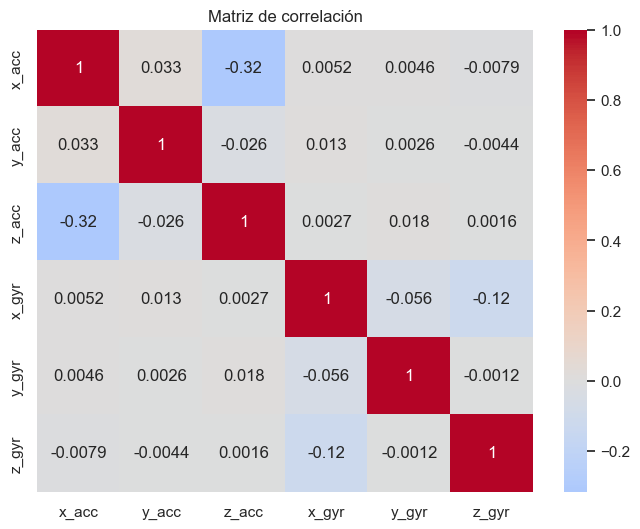

In [34]:
plt.figure(figsize=(8, 6))
sns.heatmap(correlation, annot=True, cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.show()

**Preguntas para reflexión:**

Las correlaciones son, en general, bajas cuando se comparan señales provenientes de diferentes sensores o entre ejes distintos. Las correlaciones más altas se encuentran principalmente entre los ejes de un mismo sensor (por ejemplo, entre x_acc y z_acc, o entre x_gyr y z_gyr).

Las bajas correlaciones entre acelerómetro y giroscopio indica que no hay redundancia de información entre ellos. Por lo tanto, sugiere que ambos sensores contribuyen a la predicción y que su combinación puede mejorar el desempeño del modelo.

# Flexible Classification Framework

This framework provides a comprehensive and flexible solution for training classification models on the HAR (Human Activity Recognition) dataset.

In [63]:
# Selecciono el Phone Accelerometer para el analisis de actividades
#Hago una subseleccion usuarios para reducir el tiempo de computo
Ph_acc_sub = Ph_acc.loc[
    ((Ph_acc["User"] == "a") | (Ph_acc["User"] == "c") | (Ph_acc["User"] == "g"))
]

In [71]:
#Entreno un modelo de random forest
FEATURES = ['x', 'y', 'z']
TARGET = 'gt'
MODEL_TYPE = 'random_forest'

In [ ]:
#import sys
#print(sys.executable)
#!{sys.executable} -m pip install scikit-learn

/home/rocio/miniconda3/bin/python


In [43]:
import time

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

In [81]:
#Preparacion de los datos
# Get numeric columns for features
numeric_cols = Ph_acc_sub.select_dtypes(include=[np.number]).columns.tolist()
print("Available numeric columns for features:", numeric_cols)

# Get categorical columns for target
categorical_cols = Ph_acc_sub.select_dtypes(include=["object"]).columns.tolist()
print("Available categorical columns for target:", categorical_cols)
print("\n" + "=" * 70)

# Validate feature selection
invalid_features = [f for f in FEATURES if f not in numeric_cols]
if invalid_features:
    raise ValueError(
        f"Invalid features selected: {invalid_features}. Available: {numeric_cols}"
    )

# Validate target selection
if TARGET not in categorical_cols:
    raise ValueError(
        f"Invalid target selected: {TARGET}. Available: {categorical_cols}"
    )

# Prepare the data
X = StandardScaler().fit_transform(Ph_acc_sub.loc[::100, FEATURES].values)
y = Ph_acc_sub.loc[::100, TARGET].values

# Check for missing values
print("\nData Summary:")
print(f"  Features (X): {FEATURES}")
print(f"  Target (y): {TARGET}")
print(f"  Shape of X: {X.shape}")
print(f"  Shape of y: {y.shape}")
print(f"  Missing values in X: {np.isnan(X).sum()}")

# Show target distribution
print(f"\nTarget distribution ({TARGET}):")
target_counts = np.unique(y, return_counts=True)
print(target_counts)
print(f"\nNumber of classes: {len(target_counts[0])}")
print("=" * 70 + "\n")

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


Available numeric columns for features: ['Index', 'Arrival_Time', 'Creation_Time', 'x', 'y', 'z']
Available categorical columns for target: ['User', 'Model', 'Device', 'gt', 'activity_type']


Data Summary:
  Features (X): ['x', 'y', 'z']
  Target (y): activity_type
  Shape of X: (36857, 3)
  Shape of y: (36857,)
  Missing values in X: 0

Target distribution (activity_type):
(array(['Dinamica', 'Estatica'], dtype=object), array([23586, 13271]))

Number of classes: 2



In [82]:
#Entrenamiento
models = {
    "logistic": LogisticRegression(random_state=42, max_iter=1000),
    "random_forest": RandomForestClassifier(random_state=42, n_estimators=100),
    "decision_tree": DecisionTreeClassifier(random_state=42, max_leaf_nodes=2),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "svm": SVC(random_state=42),
}

if MODEL_TYPE not in models:
    raise ValueError(
        f"Invalid model type: {MODEL_TYPE}. Available: {list(models.keys())}"
    )

print(f"Training {MODEL_TYPE.upper().replace('_', ' ')} classifier...")
classifier = models[MODEL_TYPE]
start_time = time.time()
classifier.fit(X_train, y_train)
end_time = time.time()
training_time = end_time - start_time
print(f"Training time: {training_time:.2f} seconds")

# Make predictions
start_time = time.time()
y_pred = classifier.predict(X_test)
y_pred_train = classifier.predict(X_train)
end_time = time.time()
prediction_time = end_time - start_time
print(f"Prediction time: {prediction_time:.2f} seconds")


Training LOGISTIC classifier...
Training time: 0.11 seconds
Prediction time: 0.00 seconds


In [ ]:
#Random forest para distintas actividades
print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(f"\nModel: {MODEL_TYPE.upper().replace('_', ' ')}")
print(f"Features: {FEATURES}")
print(f"Target: {TARGET}")
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")


MODEL PERFORMANCE

Model: RANDOM FOREST
Features: ['x', 'y', 'z']
Target: gt

Training Accuracy: 0.9983
Test Accuracy: 0.6609


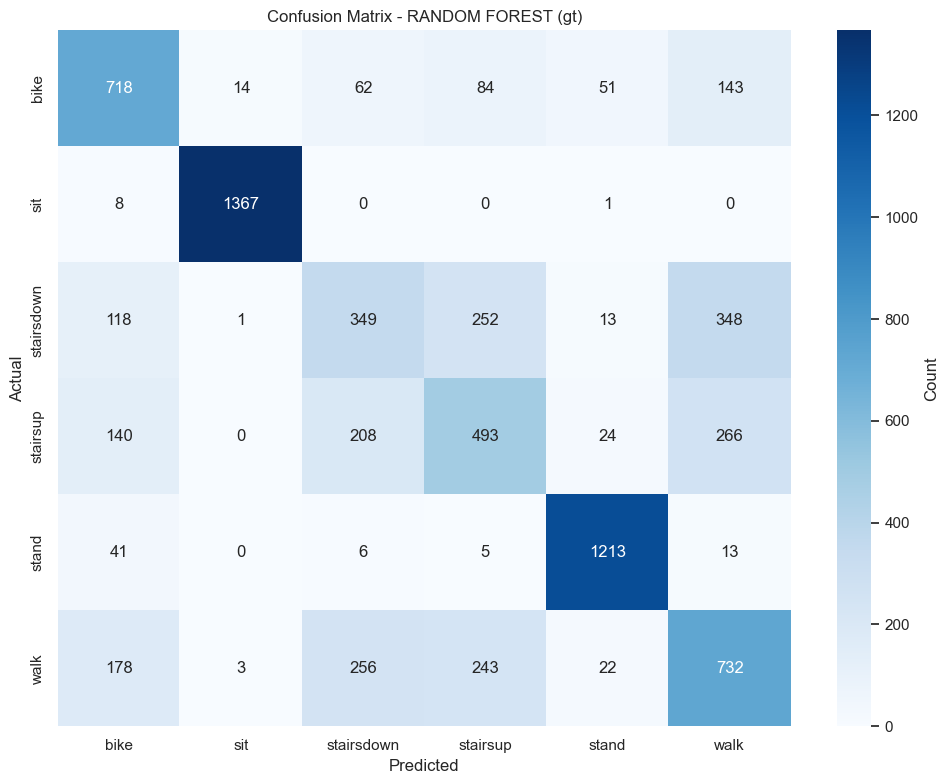

In [ ]:
#Visualizo los resultados 
# Get class names for reporting
class_names = sorted(Ph_acc_sub[TARGET].unique())
cm = confusion_matrix(y_test, y_pred)

#  Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Count"},
)
plt.title(f"Confusion Matrix - {MODEL_TYPE.upper().replace('_', ' ')} ({TARGET})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [79]:
actividad_casos = Ph_acc_sub.groupby("gt").size().sort_values(ascending=True)
print(actividad_casos)

gt
bike          535695
stairsdown    539858
stairsup      566012
stand         639083
sit           687969
walk          717033
dtype: int64


In [ ]:
# Si modelo directamente el tipo de actividad 

FEATURES = ['x', 'y', 'z']      # Select features
TARGET = 'activity_type'        # Select target variable
MODEL_TYPE = 'logistic'        # Select model type

#Ejecuto nuevamente las celdas de preparacion, entrenamiento y evaluacion del modelo anteriores

In [ ]:
#Logistic para la clasificacion de tipo de actividad

print("\n" + "=" * 70)
print("MODEL PERFORMANCE")
print("=" * 70)
print(f"\nModel: {MODEL_TYPE.upper().replace('_', ' ')}")
print(f"Features: {FEATURES}")
print(f"Target: {TARGET}")
print(f"\nTraining Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_pred):.4f}")



MODEL PERFORMANCE

Model: LOGISTIC
Features: ['x', 'y', 'z']
Target: activity_type

Training Accuracy: 0.6919
Test Accuracy: 0.6880


In [87]:
# Get class names for reporting
class_names = sorted(Ph_acc_sub[TARGET].unique())
print(class_names)
cm = confusion_matrix(y_test, y_pred)


['Dinamica', 'Estatica']


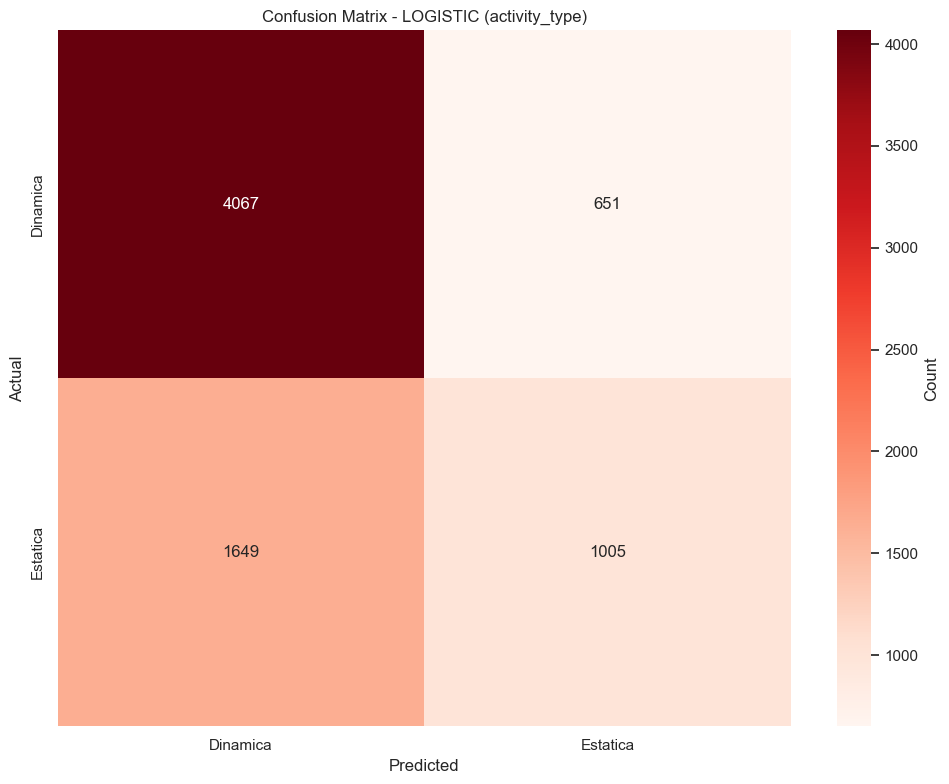

In [88]:
#Visualizo los resultados para Logistic

#  Matrix Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=class_names,
    yticklabels=class_names,
    cbar_kws={"label": "Count"},
)
plt.title(f"Confusion Matrix - {MODEL_TYPE.upper().replace('_', ' ')} ({TARGET})")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

In [89]:
actividad_casos = Ph_acc_sub.groupby("activity_type").size().sort_values(ascending=True)
print(actividad_casos)

activity_type
Estatica    1327052
Dinamica    2358598
dtype: int64


La predictibilidad es mayor en actividades de carácter pasivo, como stand y sit, mientras que disminuye en actividades dinámicas, como walk y bike. En particular, el desempeño del modelo es más bajo en stairsdown y stairsup.

Si bien stand y sit cuentan con una mayor cantidad de datos en comparación con actividades como bike, no así como walk, que tiene el mayor número de datos de todas las actividades. Esta diferencia en el tamaño de la muestra no parece tener tanta relevancia en la performance del modelo.

Al agrupar las actividades en categorías más amplias, por ejemplo, dinámicas versus estáticas, y considerando el modelo logístico, se observa una mejora en la capacidad predictiva del modelo para las actividades dinámicas, aunque también aumenta la diferencia en el tamaño de las muestras entre dinámicas y estáticas. 